# Mini Project: RNN Comparison with Time Series Models

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date, timedelta

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

print(f"TensorFlow version : {tf.__version__}")
print("All libraries loaded successfully.")

TensorFlow version : 2.19.0
All libraries loaded successfully.


## Load & Prepare NIFTY 50 Data

In [ ]:
end_date   = date.today()
start_date = end_date - timedelta(days=365 * 20)

print(f"Downloading NIFTY 50: {start_date} → {end_date}")
raw = yf.download('^NSEI', start=str(start_date), end=str(end_date), progress=False)
Xt  = raw['Close'].dropna()
print(f"Total trading days: {len(Xt)}")

TEST_SIZE  = 5
VALID_SIZE = 30
LOOK_BACK  = 60

prices = Xt.values.reshape(-1, 1)
dates  = Xt.index

train_prices = prices[:-(TEST_SIZE + VALID_SIZE)]
valid_prices = prices[-(TEST_SIZE + VALID_SIZE):-TEST_SIZE]
test_prices  = prices[-TEST_SIZE:]
test_dates   = dates[-TEST_SIZE:]

print(f"Train : {len(train_prices):,} rows")
print(f"Valid : {len(valid_prices):,} rows")
print(f"Test  : {len(test_prices):,} rows  ← {test_dates[0].date()} to {test_dates[-1].date()}")

Total trading days: 4555
Train : 4,520 rows
Valid : 30 rows
Test  : 5 rows  ← 2026-04-08 to 2026-04-15


In [ ]:
raw

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0
...,...,...,...,...,...
2026-04-08,23997.349609,24025.150391,23828.500000,23855.150391,639300
2026-04-09,23775.099609,23990.750000,23682.800781,23909.050781,466600


## Normalise & Build Supervised Sequences

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_prices)

train_s = scaler.transform(train_prices)
valid_s = scaler.transform(valid_prices)
test_s  = scaler.transform(test_prices)

def make_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back, 0])
        y.append(data[i + look_back, 0])
    return np.array(X)[..., np.newaxis], np.array(y)   # (N, L, 1), (N,)

# For training, use train + valid as one block for sequence construction
train_valid_s = np.vstack([train_s, valid_s])
X_train, y_train = make_sequences(train_valid_s, LOOK_BACK)

# For test: we need the last LOOK_BACK steps from train+valid + the 5 test steps
context       = np.vstack([train_valid_s[-LOOK_BACK:], test_s])
X_test, y_test = make_sequences(context, LOOK_BACK)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")

X_train: (4490, 60, 1)  y_train: (4490,)
X_test : (5, 60, 1)   y_test : (5,)


## Train, Predict & Evaluate an RNN Model

In [ ]:
def build_and_train(rnn_type: str, X_tr, y_tr, X_te, y_te, look_back, epochs=100):
    """
    Build, train, and evaluate a single-layer RNN model.
    rnn_type: 'SimpleRNN' | 'LSTM' | 'GRU'
    Returns: (history, y_pred_rescaled, metrics_dict)
    """
    CELL = {'SimpleRNN': SimpleRNN, 'LSTM': LSTM, 'GRU': GRU}[rnn_type]

    model = Sequential([
        CELL(units=64, input_shape=(look_back, 1), return_sequences=True),
        Dropout(0.2),
        CELL(units=32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    history = model.fit(
        X_tr, y_tr,
        validation_split=0.1,
        epochs=epochs,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )

    # Predict on test
    y_pred_s = model.predict(X_te, verbose=0).flatten()          # scaled
    y_pred   = scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
    y_true   = scaler.inverse_transform(y_te.reshape(-1,1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    stopped = es.stopped_epoch if es.stopped_epoch > 0 else epochs
    print(f"  [{rnn_type}]  epochs={stopped}  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}")
    return history, y_pred, y_true, {'rmse': rmse, 'mae': mae, 'r2': r2}


## Train SimpleRNN

 SimpleRNN 
  [SimpleRNN]  epochs=18  RMSE=1911.34  MAE=1874.62  R²=-140.2862


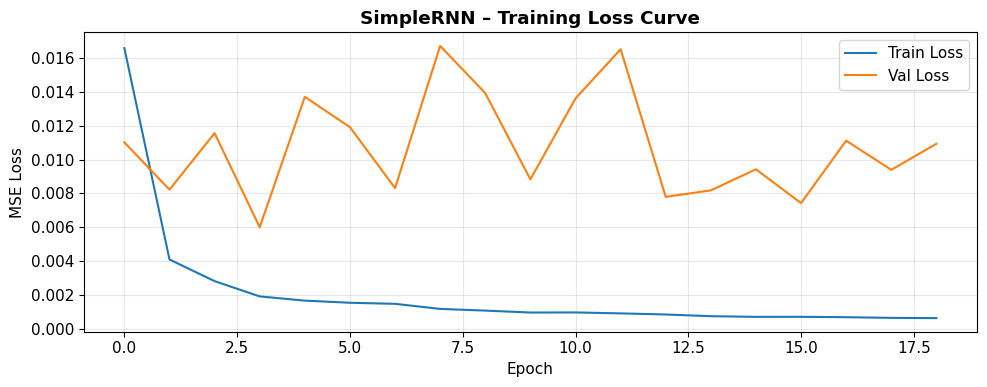

In [ ]:
print(" SimpleRNN ")
hist_rnn, pred_rnn, true_prices_nn, met_rnn = build_and_train(
    'SimpleRNN', X_train, y_train, X_test, y_test, LOOK_BACK, epochs=150
)

# Training curve
plt.figure(figsize=(10, 4))
plt.plot(hist_rnn.history['loss'],     label='Train Loss')
plt.plot(hist_rnn.history['val_loss'], label='Val Loss')
plt.title('SimpleRNN – Training Loss Curve', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mp_simplernn_loss.png', bbox_inches='tight')
plt.show()

## Train LSTM

LSTM
  [LSTM]  epochs=33  RMSE=1126.47  MAE=1118.31  R²=-48.0754


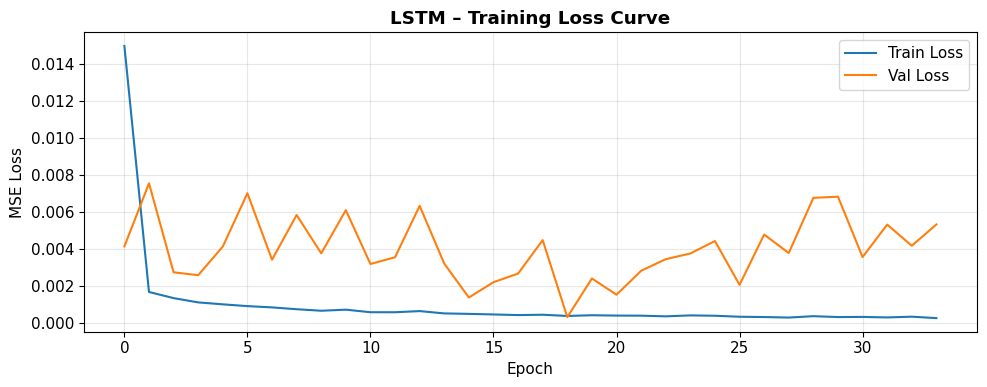

In [ ]:
print("LSTM")
hist_lstm, pred_lstm, _, met_lstm = build_and_train(
    'LSTM', X_train, y_train, X_test, y_test, LOOK_BACK, epochs=150
)

plt.figure(figsize=(10, 4))
plt.plot(hist_lstm.history['loss'],     label='Train Loss')
plt.plot(hist_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM – Training Loss Curve', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mp_lstm_loss.png', bbox_inches='tight')
plt.show()

## Train GRU

GRU
  [GRU]  epochs=17  RMSE=937.98  MAE=911.23  R²=-33.0260


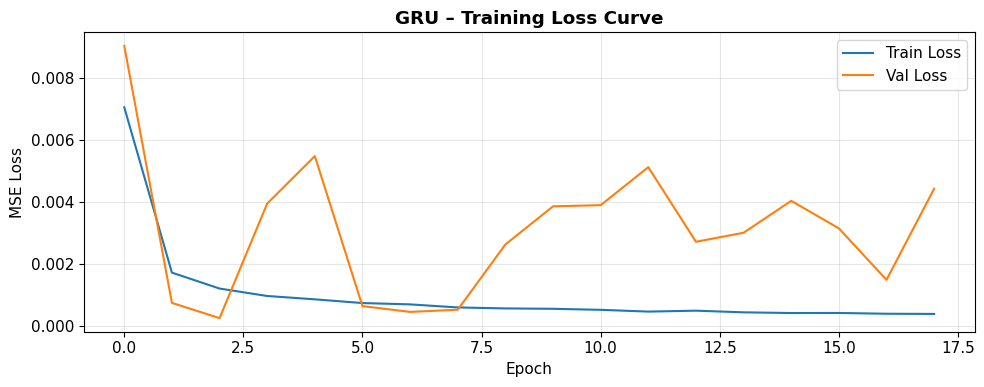

In [ ]:
print("GRU")
hist_gru, pred_gru, _, met_gru = build_and_train(
    'GRU', X_train, y_train, X_test, y_test, LOOK_BACK, epochs=150
)

plt.figure(figsize=(10, 4))
plt.plot(hist_gru.history['loss'],     label='Train Loss')
plt.plot(hist_gru.history['val_loss'], label='Val Loss')
plt.title('GRU – Training Loss Curve', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mp_gru_loss.png', bbox_inches='tight')
plt.show()

## Classical Baselines: ARIMA & ARMA+GARCH

In [ ]:
# ARIMA baselines (5 models, picks best by AIC)
train_series = Xt.iloc[:-(TEST_SIZE + VALID_SIZE)].values   # price series (not scaled)
test_series  = Xt.iloc[-TEST_SIZE:].values

arima_orders  = [(1,1,1), (2,1,2), (1,1,2), (2,1,1), (0,1,1)]
arima_results = {}

print("Fitting ARIMA models ...")
for order in arima_orders:
    try:
        m = ARIMA(train_series, order=order).fit()
        fc = m.forecast(steps=TEST_SIZE)
        rmse = np.sqrt(mean_squared_error(test_series, fc))
        mae  = mean_absolute_error(test_series, fc)
        r2   = r2_score(test_series, fc)
        arima_results[str(order)] = {
            'forecast': fc, 'aic': m.aic, 'bic': m.bic,
            'rmse': rmse, 'mae': mae, 'r2': r2
        }
        print(f"  ARIMA{order}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}")
    except Exception as e:
        print(f"  ARIMA{order} failed: {e}")

# Best ARIMA by AIC
best_arima_key = min(arima_results, key=lambda k: arima_results[k]['aic'])
print(f"\n→ Best ARIMA by AIC: {best_arima_key}")

Fitting ARIMA models ...
  ARIMA(1, 1, 1)  AIC=56077.4  BIC=56096.6  RMSE=1846.83  MAE=1839.82  R²=-130.9102
  ARIMA(2, 1, 2)  AIC=56080.3  BIC=56112.4  RMSE=1848.60  MAE=1841.59  R²=-131.1623
  ARIMA(1, 1, 2)  AIC=56078.2  BIC=56103.8  RMSE=1847.54  MAE=1840.52  R²=-131.0111
  ARIMA(2, 1, 1)  AIC=56078.2  BIC=56103.8  RMSE=1847.49  MAE=1840.46  R²=-131.0039
  ARIMA(0, 1, 1)  AIC=56075.3  BIC=56088.2  RMSE=1847.24  MAE=1840.22  R²=-130.9677

→ Best ARIMA by AIC: (0, 1, 1)


In [ ]:
# ARMA(1,1)+GARCH(1,1) baseline
print("\nFitting ARMA+GARCH model ...")
rt_train_all = np.log(Xt.iloc[:-(TEST_SIZE + VALID_SIZE)]).diff().dropna().values * 100
rt_test_true = np.log(Xt).diff().dropna().iloc[-TEST_SIZE:].values
last_price   = float(Xt.iloc[-(TEST_SIZE + VALID_SIZE + 1)])

gm = arch_model(rt_train_all, mean='ARX', lags=1, vol='GARCH', p=1, q=1, dist='Normal')
gf = gm.fit(disp='off', options={'maxiter': 500})
fc_g = gf.forecast(horizon=TEST_SIZE, reindex=False)

pred_ret_garch = fc_g.mean.values[-1] / 100
pred_price_garch = np.array([
    last_price * np.exp(np.sum(pred_ret_garch[:k+1]))
    for k in range(TEST_SIZE)
])

rmse_g = np.sqrt(mean_squared_error(test_series, pred_price_garch))
mae_g  = mean_absolute_error(test_series, pred_price_garch)
r2_g   = r2_score(test_series, pred_price_garch)
print(f"  ARMA+GARCH  RMSE={rmse_g:.2f}  MAE={mae_g:.2f}  R²={r2_g:.4f}")


Fitting ARMA+GARCH model ...
  ARMA+GARCH  RMSE=1903.05  MAE=1897.07  R²=-139.0635


## Comprehensive Comparison Table

In [ ]:
results = {
    'SimpleRNN'        : met_rnn,
    'LSTM'             : met_lstm,
    'GRU'              : met_gru,
    'ARMA+GARCH(1,1)'  : {'rmse': rmse_g, 'mae': mae_g, 'r2': r2_g},
}
for k, v in arima_results.items():
    results[f'ARIMA{k}'] = {'rmse': v['rmse'], 'mae': v['mae'], 'r2': v['r2']}

df_results = pd.DataFrame(results).T.rename(columns={'rmse':'RMSE','mae':'MAE','r2':'R²'})
df_results = df_results.astype(float).round({'RMSE':2, 'MAE':2, 'R²':4})
df_results['Rank (RMSE)'] = df_results['RMSE'].rank().astype(int)
df_results.sort_values('RMSE', inplace=True)

print("=" * 60)
print(" MODEL COMPARISON (sorted by RMSE ↑ = better)")
print("=" * 60)
print(df_results.to_string())
print("=" * 60)
best_model = df_results.index[0]
print(f"\n✓ Best model: {best_model} (lowest RMSE = {df_results.loc[best_model,'RMSE']:.2f})")

 MODEL COMPARISON (sorted by RMSE ↑ = better)
                    RMSE      MAE        R²  Rank (RMSE)
GRU               937.98   911.23  -33.0260            1
LSTM             1126.47  1118.31  -48.0754            2
ARIMA(1, 1, 1)   1846.83  1839.82 -130.9102            3
ARIMA(0, 1, 1)   1847.24  1840.22 -130.9677            4
ARIMA(2, 1, 1)   1847.49  1840.46 -131.0039            5
ARIMA(1, 1, 2)   1847.54  1840.52 -131.0111            6
ARIMA(2, 1, 2)   1848.60  1841.59 -131.1623            7
ARMA+GARCH(1,1)  1903.05  1897.07 -139.0635            8
SimpleRNN        1911.34  1874.62 -140.2862            9

✓ Best model: GRU (lowest RMSE = 937.98)


## Individual Forecast vs True Price Plots (All Models)

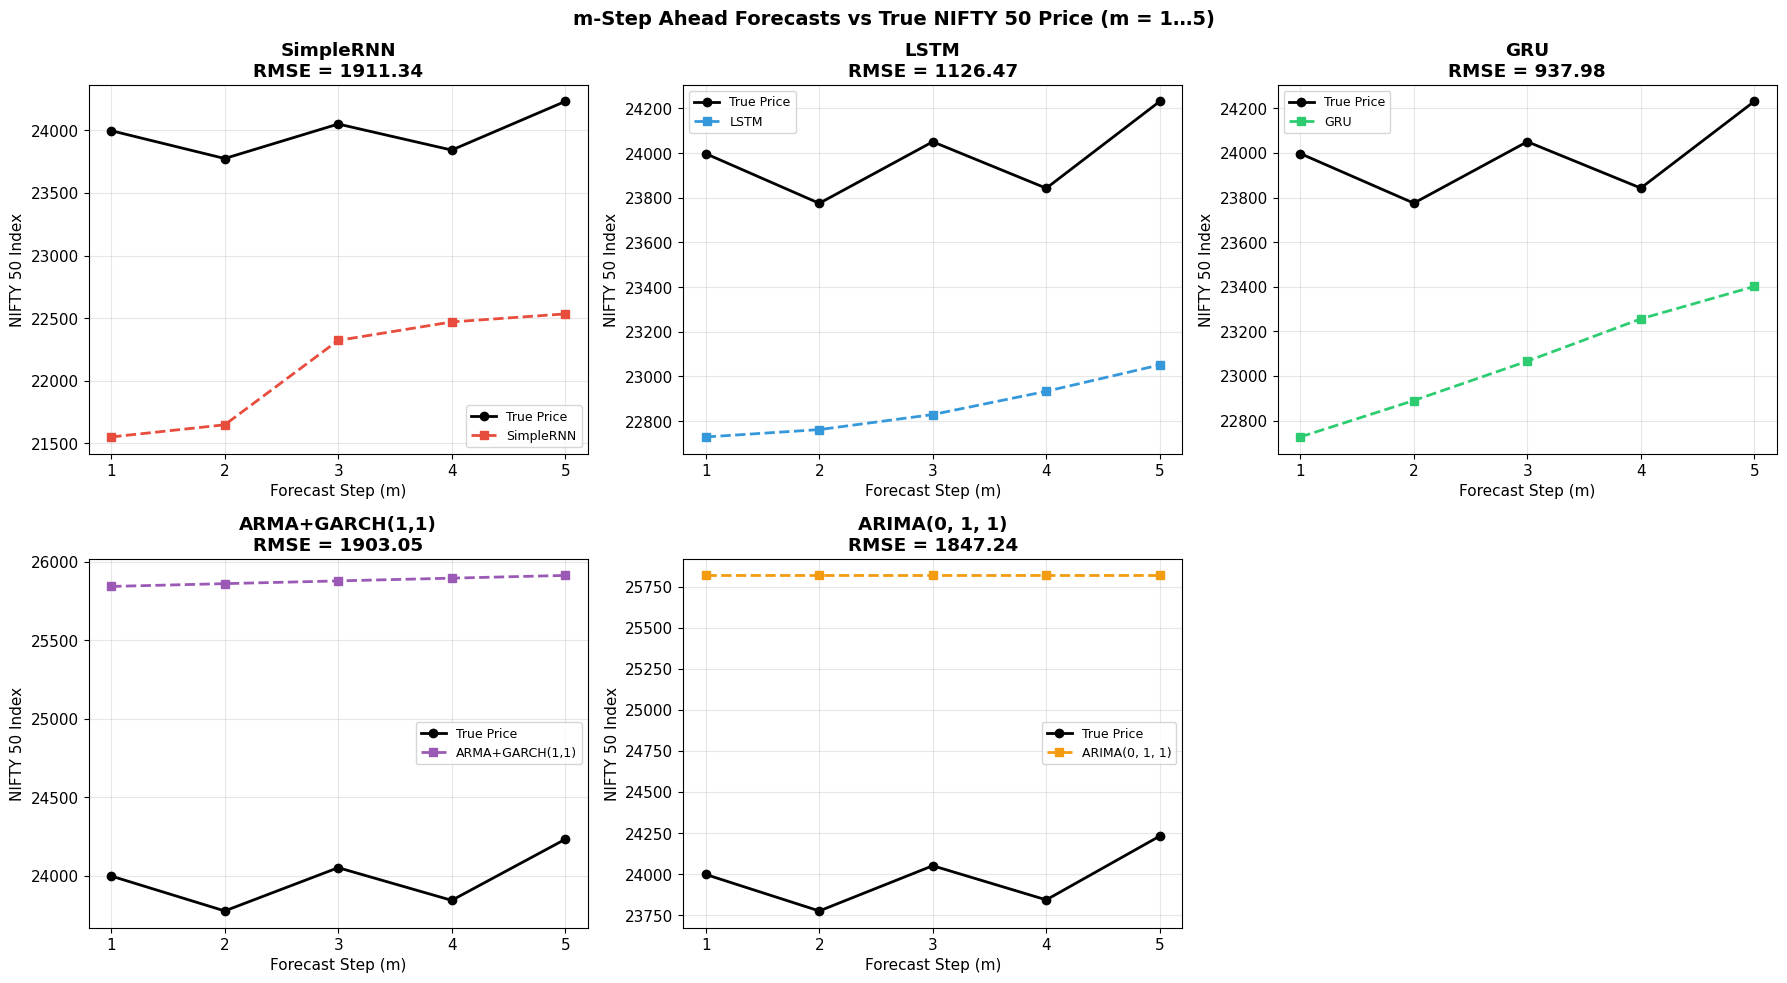

In [ ]:
model_preds = {
    'SimpleRNN'        : pred_rnn,
    'LSTM'             : pred_lstm,
    'GRU'              : pred_gru,
    'ARMA+GARCH(1,1)'  : pred_price_garch,
    f'ARIMA{best_arima_key}': arima_results[best_arima_key]['forecast'],
}

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

x_ticks = range(1, TEST_SIZE + 1)
for idx, (name, pred) in enumerate(model_preds.items()):
    ax = axes_flat[idx]
    ax.plot(x_ticks, test_series,  'ko-', linewidth=2,   markersize=6, label='True Price')
    ax.plot(x_ticks, pred,         's--', color=colors[idx], linewidth=2,
            markersize=6, label=f'{name}')
    rmse_val = np.sqrt(mean_squared_error(test_series, pred))
    ax.set_title(f'{name}\nRMSE = {rmse_val:.2f}', fontweight='bold')
    ax.set_xlabel('Forecast Step (m)'); ax.set_ylabel('NIFTY 50 Index')
    ax.set_xticks(list(x_ticks))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Hide last empty subplot
axes_flat[-1].axis('off')

plt.suptitle('m-Step Ahead Forecasts vs True NIFTY 50 Price (m = 1…5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mp_individual_forecasts.png', bbox_inches='tight')
plt.show()

## Combined Overlay: All Models on One Plot

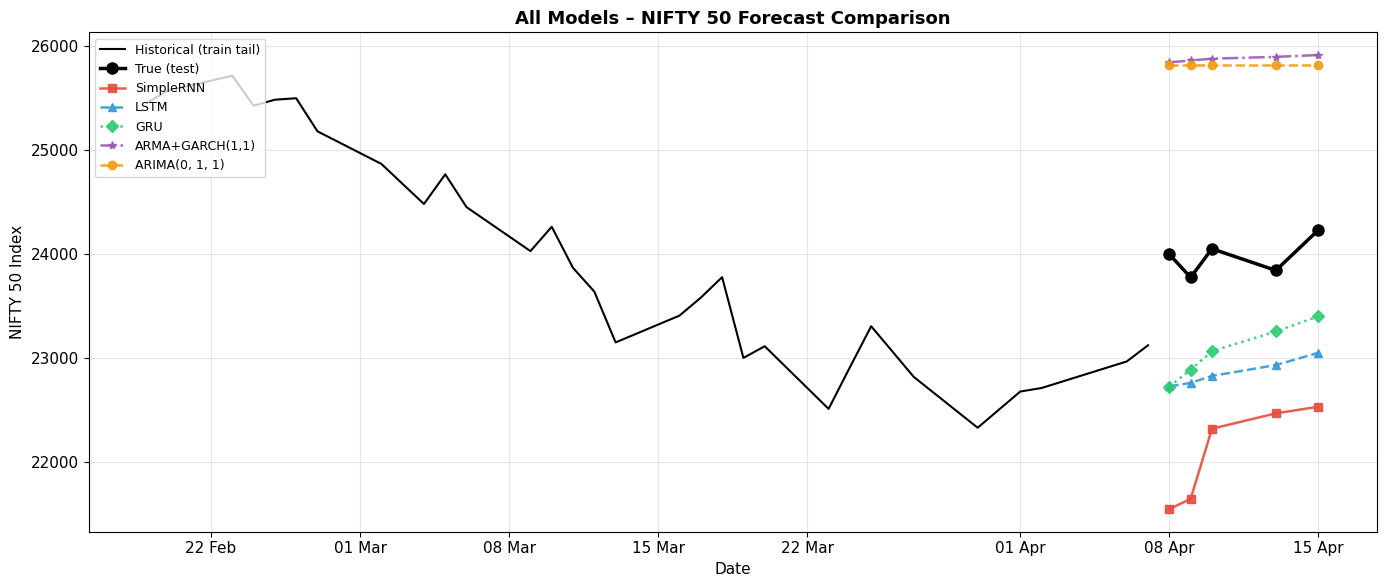

In [ ]:
# Show last 30 training days + 5 test days for context
tail_n   = 30
tail_idx = Xt.iloc[-(TEST_SIZE + tail_n): -TEST_SIZE]
tail_val = tail_idx.values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(tail_idx.index, tail_val, color='black', linewidth=1.5, label='Historical (train tail)')
ax.plot(test_dates, test_series, 'ko-', linewidth=2.5, markersize=8, label='True (test)', zorder=10)

line_styles = ['-s', '--^', ':D', '-.*', '--o']
for (name, pred), ls, c in zip(model_preds.items(), line_styles, colors):
    ax.plot(test_dates, pred, ls, color=c, linewidth=1.8, markersize=6, label=name, alpha=0.9)

ax.set_title('All Models – NIFTY 50 Forecast Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('NIFTY 50 Index')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mp_combined_forecast.png', bbox_inches='tight')
plt.show()

## Metric Bar Charts

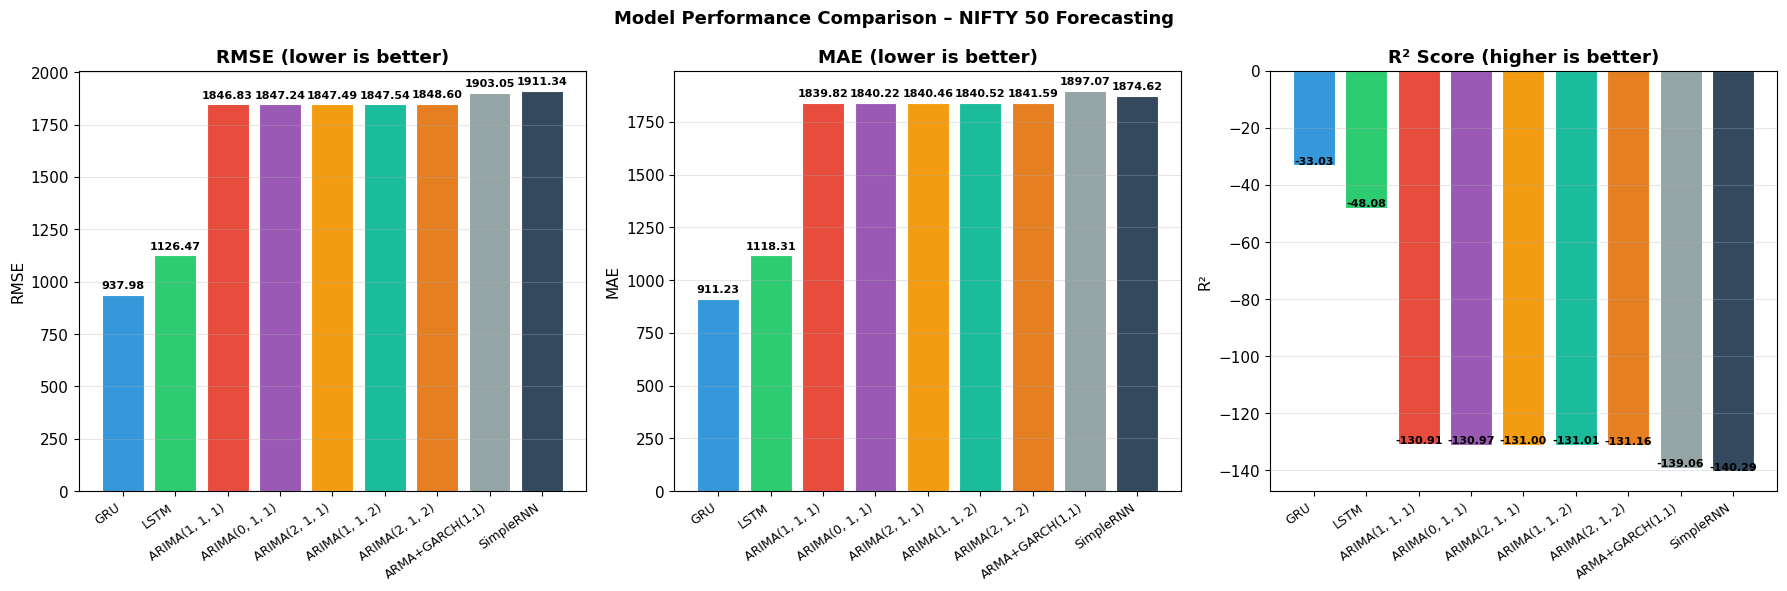

In [ ]:
model_names = df_results.index.tolist()
rmse_vals   = df_results['RMSE'].values
mae_vals    = df_results['MAE'].values
r2_vals     = df_results['R²'].values

x = np.arange(len(model_names))
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12',
              '#1abc9c', '#e67e22', '#95a5a6', '#34495e']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, vals, title, ylabel, ascending in zip(
    axes,
    [rmse_vals, mae_vals, r2_vals],
    ['RMSE (lower is better)', 'MAE (lower is better)', 'R² Score (higher is better)'],
    ['RMSE', 'MAE', 'R²'],
    [True, True, False]
):
    bars = ax.bar(x, vals, color=bar_colors[:len(model_names)], edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis='y')
    # Annotate bar tops
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model Performance Comparison – NIFTY 50 Forecasting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mp_metric_bars.png', bbox_inches='tight')
plt.show()

## Learning Curve Comparison (RNN Models)

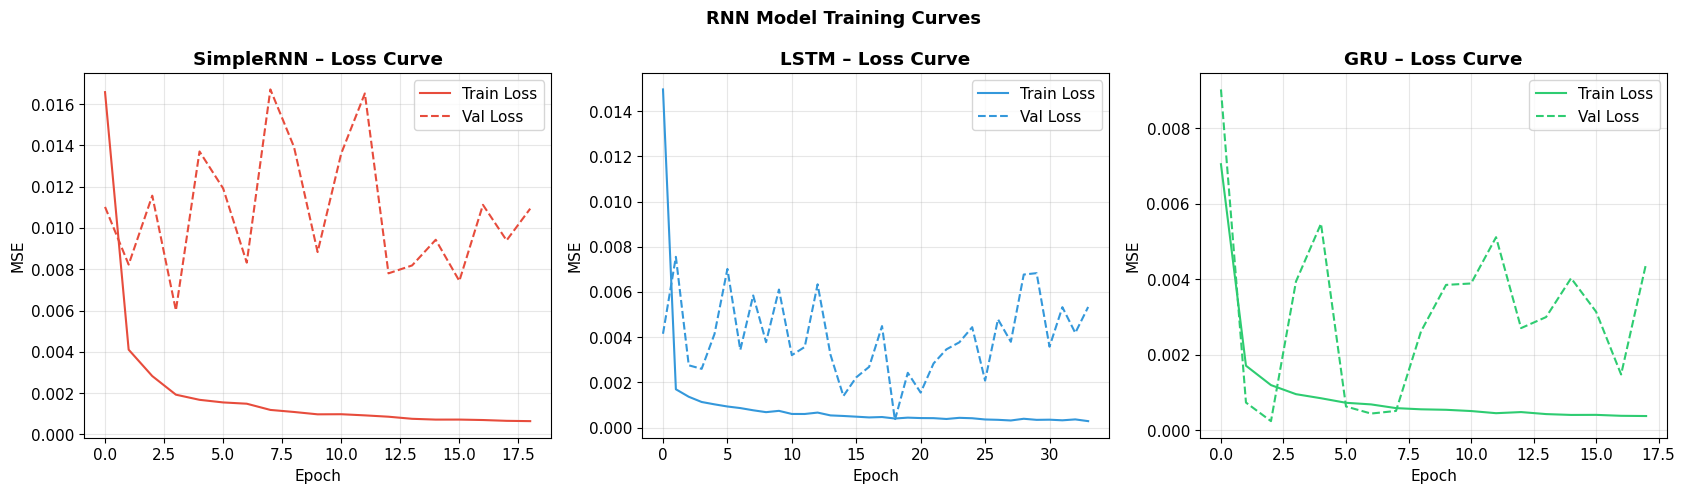

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
rnn_hists = [
    ('SimpleRNN', hist_rnn, '#e74c3c'),
    ('LSTM',      hist_lstm, '#3498db'),
    ('GRU',       hist_gru,  '#2ecc71'),
]

for ax, (name, h, c) in zip(axes, rnn_hists):
    ax.plot(h.history['loss'],     color=c,           linewidth=1.5, label='Train Loss')
    ax.plot(h.history['val_loss'], color=c, linestyle='--', linewidth=1.5, label='Val Loss')
    ax.set_title(f'{name} – Loss Curve', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('RNN Model Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mp_all_loss_curves.png', bbox_inches='tight')
plt.show()

## Residual / Error Analysis

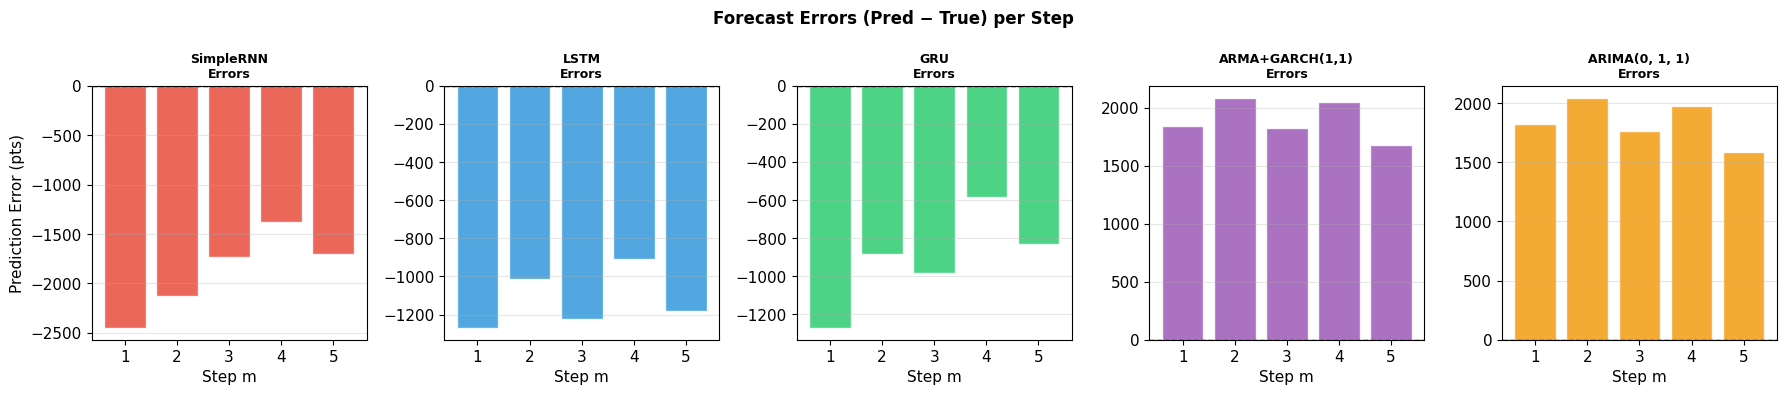

In [ ]:
fig, axes = plt.subplots(1, len(model_preds), figsize=(18, 4), sharey=False)

for ax, (name, pred), c in zip(axes, model_preds.items(), colors):
    pred = np.asarray(pred).reshape(-1)          # ensure 1D
    true = np.asarray(test_series).reshape(-1)   # ensure 1D

    errors = pred - true

    ax.bar(range(1, TEST_SIZE+1), errors, color=c, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=1.0, linestyle='--')
    ax.set_title(f'{name}\nErrors', fontsize=9, fontweight='bold')
    ax.set_xlabel('Step m')
    if ax == axes[0]:
        ax.set_ylabel('Prediction Error (pts)')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Forecast Errors (Pred − True) per Step', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mp_error_bars.png', bbox_inches='tight')
plt.show()

## Final Summary Table

In [ ]:
print("\n" + "=" * 68)
print("         FINAL PERFORMANCE SUMMARY – NIFTY 50 FORECASTING")
print("=" * 68)
print(f"{'Model':<26}  {'RMSE':>8}  {'MAE':>8}  {'R²':>8}  {'Category'}")
print("-" * 68)
categories = {
    'SimpleRNN': 'Deep Learning',
    'LSTM'     : 'Deep Learning',
    'GRU'      : 'Deep Learning',
    'ARMA+GARCH(1,1)': 'Statistical'
}
for idx_name in df_results.index:
    row = df_results.loc[idx_name]
    cat = categories.get(idx_name, 'Statistical')
    marker = ' ← Best' if idx_name == best_model else ''
    print(f"{idx_name:<26}  {row['RMSE']:>8.2f}  {row['MAE']:>8.2f}  {row['R²']:>8.4f}  {cat}{marker}")
print("=" * 68)


         FINAL PERFORMANCE SUMMARY – NIFTY 50 FORECASTING
Model                           RMSE       MAE        R²  Category
--------------------------------------------------------------------
GRU                           937.98    911.23  -33.0260  Deep Learning ← Best
LSTM                         1126.47   1118.31  -48.0754  Deep Learning
ARIMA(1, 1, 1)               1846.83   1839.82  -130.9102  Statistical
ARIMA(0, 1, 1)               1847.24   1840.22  -130.9677  Statistical
ARIMA(2, 1, 1)               1847.49   1840.46  -131.0039  Statistical
ARIMA(1, 1, 2)               1847.54   1840.52  -131.0111  Statistical
ARIMA(2, 1, 2)               1848.60   1841.59  -131.1623  Statistical
ARMA+GARCH(1,1)              1903.05   1897.07  -139.0635  Statistical
SimpleRNN                    1911.34   1874.62  -140.2862  Deep Learning
